Starting demand forecasting project...

Baseline Test MAE:
Naive Forecast:          26.10
Moving Average (4):      22.68
EMA (span=4):            22.03

EMA Span Comparison:
 Span       MAE
    2 24.026370
    3 22.898463
    4 22.691197
    5 22.758655
    6 22.865524
    8 23.026738
   12 23.268261

Random Forest v1 Test MAE: 20.83
Random Forest v2 Test MAE: 18.98

Random Forest v3 Performance:
MAE:  17.77
RMSE: 21.97
MAPE: 8.95%
Bias: 5.41

MODEL COMPARISON
                   Model  Test MAE
        Random Forest v3 17.766667
        Random Forest v2 18.976429
        Random Forest v1 20.826429
            EMA (span=4) 22.031597
Moving Average (4 weeks) 22.678571
          Naive Forecast 26.095238

V3 FEATURE IMPORTANCE
        Feature  Importance
      Promotion    0.227733
           Week    0.192671
 Rolling_Mean_4    0.113600
          Lag_1    0.082392
          Lag_8    0.082221
 Rolling_Mean_8    0.070273
          Lag_2    0.050490
          Lag_3    0.044731
          Lag_5

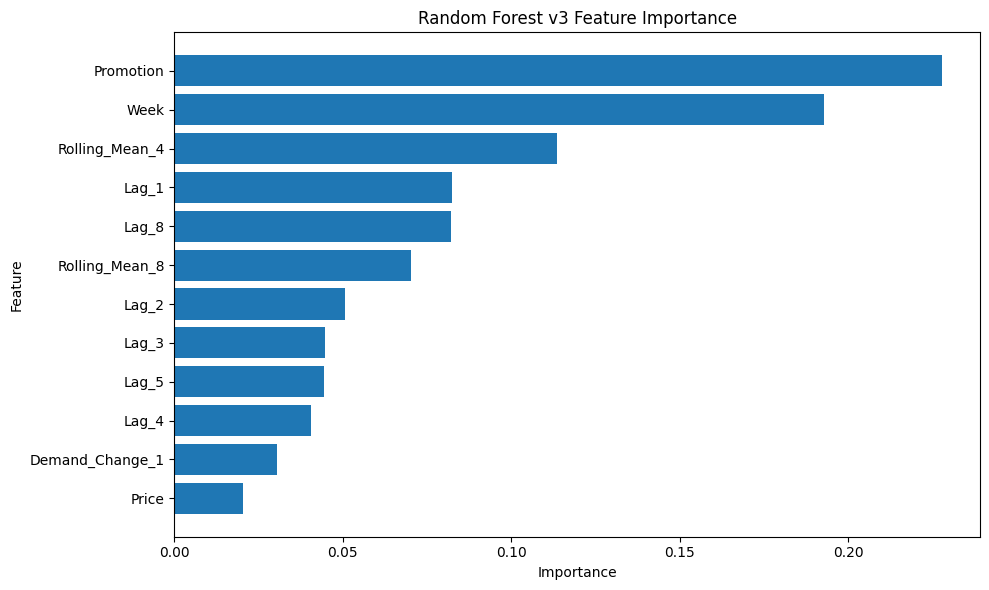


V3 FORECAST RESULTS
      Date  Demand   Forecast      Error  Absolute_Error
2025-08-10   225.0 204.266667  20.733333       20.733333
2025-08-17   197.0 205.080000  -8.080000        8.080000
2025-08-24   172.0 196.500000 -24.500000       24.500000
2025-08-31   251.0 214.386667  36.613333       36.613333
2025-09-07   175.0 196.263333 -21.263333       21.263333
2025-09-14   196.0 184.770000  11.230000       11.230000
2025-09-21   180.0 173.890000   6.110000        6.110000
2025-09-28   156.0 181.456667 -25.456667       25.456667
2025-10-05   195.0 174.220000  20.780000       20.780000
2025-10-12   172.0 174.160000  -2.160000        2.160000
2025-10-19   164.0 186.926667 -22.926667       22.926667
2025-10-26   155.0 172.603333 -17.603333       17.603333
2025-11-02   195.0 181.333333  13.666667       13.666667
2025-11-09   177.0 180.143333  -3.143333        3.143333
2025-11-16   184.0 178.546667   5.453333        5.453333
2025-11-23   226.0 183.223333  42.776667       42.776667
2025-11-30

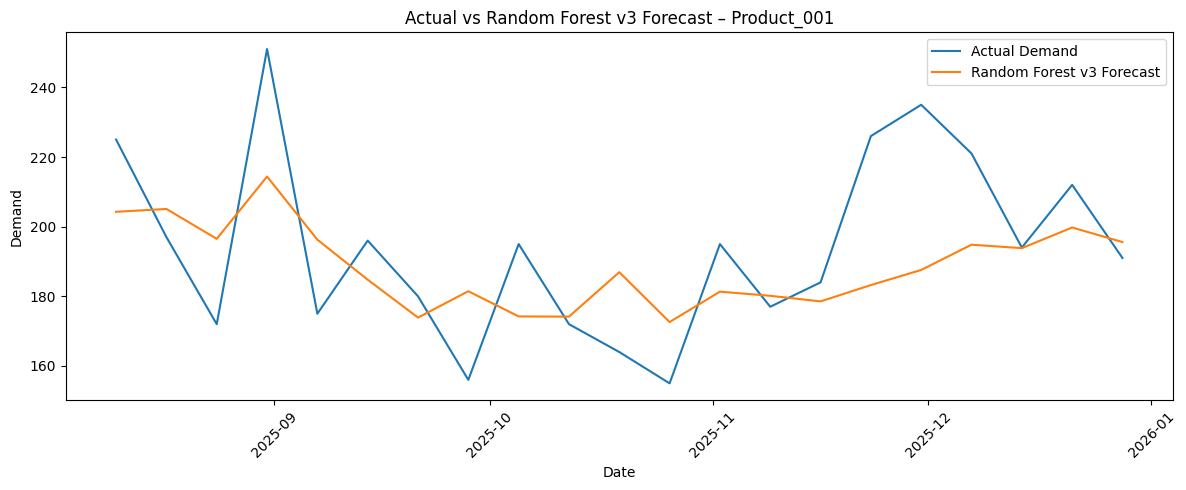


FINAL SUMMARY
Best model: Random Forest v3
Best Test MAE: 17.77
V3 improvement vs Naive Forecast: 31.9%

Project completed successfully.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor


# ============================================================
# 1. LOAD DATA
# ============================================================

print("Starting demand forecasting project...")

df = pd.read_csv("../dataset/raw/demand_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

product_data = df[df["Product"] == "Product_001"].copy()
product_data = product_data.sort_values("Date").reset_index(drop=True)


# ============================================================
# 2. TRAIN / TEST SPLIT
# ============================================================

split_index = int(len(product_data) * 0.8)

train = product_data.iloc[:split_index].copy()
test = product_data.iloc[split_index:].copy()

test_start_date = test["Date"].min()


# ============================================================
# 3. BASELINE FORECASTS
# ============================================================

# Naive forecast: previous week's demand
product_data["Naive_Forecast"] = (
    product_data["Demand"].shift(1)
)

# 4-week moving average
product_data["MA_4_Forecast"] = (
    product_data["Demand"]
    .rolling(window=4)
    .mean()
    .shift(1)
)

# Exponential moving average
product_data["EMA_Forecast"] = (
    product_data["Demand"]
    .ewm(span=4, adjust=False)
    .mean()
    .shift(1)
)


# ============================================================
# 4. BASELINE TEST PERFORMANCE
# ============================================================

test["Naive_Forecast"] = (
    product_data["Naive_Forecast"]
    .iloc[split_index:]
    .values
)

test["MA_4_Forecast"] = (
    product_data["MA_4_Forecast"]
    .iloc[split_index:]
    .values
)

test["EMA_Forecast"] = (
    product_data["EMA_Forecast"]
    .iloc[split_index:]
    .values
)

mae_naive_test = mean_absolute_error(
    test["Demand"],
    test["Naive_Forecast"]
)

mae_moving_average_test = mean_absolute_error(
    test["Demand"],
    test["MA_4_Forecast"]
)

mae_ema_test = mean_absolute_error(
    test["Demand"],
    test["EMA_Forecast"]
)

print("\nBaseline Test MAE:")
print(f"Naive Forecast:          {mae_naive_test:.2f}")
print(f"Moving Average (4):      {mae_moving_average_test:.2f}")
print(f"EMA (span=4):            {mae_ema_test:.2f}")


# ============================================================
# 5. EMA SPAN COMPARISON
# ============================================================

ema_results = []

for span in [2, 3, 4, 5, 6, 8, 12]:

    forecast = (
        product_data["Demand"]
        .ewm(span=span, adjust=False)
        .mean()
        .shift(1)
    )

    valid_data = pd.DataFrame({
        "Demand": product_data["Demand"],
        "Forecast": forecast
    }).dropna()

    mae = mean_absolute_error(
        valid_data["Demand"],
        valid_data["Forecast"]
    )

    ema_results.append({
        "Span": span,
        "MAE": mae
    })

ema_results = pd.DataFrame(ema_results)

print("\nEMA Span Comparison:")
print(ema_results.to_string(index=False))


# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

# Lag features
product_data["Lag_1"] = product_data["Demand"].shift(1)
product_data["Lag_2"] = product_data["Demand"].shift(2)
product_data["Lag_3"] = product_data["Demand"].shift(3)
product_data["Lag_4"] = product_data["Demand"].shift(4)
product_data["Lag_5"] = product_data["Demand"].shift(5)
product_data["Lag_8"] = product_data["Demand"].shift(8)

# Rolling averages
product_data["Rolling_Mean_4"] = (
    product_data["Demand"]
    .rolling(window=4)
    .mean()
    .shift(1)
)

product_data["Rolling_Mean_8"] = (
    product_data["Demand"]
    .rolling(window=8)
    .mean()
    .shift(1)
)

# Week of year
product_data["Week"] = (
    product_data["Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

# Change in demand from previous week
product_data["Demand_Change_1"] = (
    product_data["Demand"].shift(1)
    - product_data["Demand"].shift(2)
)


# ============================================================
# 7. DEFINE MODEL FEATURES
# ============================================================

target = "Demand"

# Random Forest v1
features_v1 = [
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Rolling_Mean_4",
    "Price",
    "Promotion"
]

# Random Forest v2
features_v2 = [
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Rolling_Mean_4",
    "Price",
    "Promotion",
    "Week"
]

# Random Forest v3
features_v3 = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_4",
    "Lag_5",
    "Lag_8",
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Price",
    "Promotion",
    "Week",
    "Demand_Change_1"
]


# ============================================================
# 8. CREATE ML DATASETS
# ============================================================

ml_data_v1 = product_data.dropna(
    subset=features_v1 + [target]
).copy()

ml_data_v2 = product_data.dropna(
    subset=features_v2 + [target]
).copy()

ml_data_v3 = product_data.dropna(
    subset=features_v3 + [target]
).copy()


# ============================================================
# 9. TIME-BASED TRAIN / TEST SPLITS
# ============================================================

# -------------------------
# V1
# -------------------------

train_ml_v1 = ml_data_v1[
    ml_data_v1["Date"] < test_start_date
].copy()

test_ml_v1 = ml_data_v1[
    ml_data_v1["Date"] >= test_start_date
].copy()


# -------------------------
# V2
# -------------------------

train_ml_v2 = ml_data_v2[
    ml_data_v2["Date"] < test_start_date
].copy()

test_ml_v2 = ml_data_v2[
    ml_data_v2["Date"] >= test_start_date
].copy()


# -------------------------
# V3
# -------------------------

train_ml_v3 = ml_data_v3[
    ml_data_v3["Date"] < test_start_date
].copy()

test_ml_v3 = ml_data_v3[
    ml_data_v3["Date"] >= test_start_date
].copy()


# ============================================================
# 10. RANDOM FOREST V1
# ============================================================

X_train_v1 = train_ml_v1[features_v1]
y_train_v1 = train_ml_v1[target]

X_test_v1 = test_ml_v1[features_v1]
y_test_v1 = test_ml_v1[target]

model_v1 = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model_v1.fit(
    X_train_v1,
    y_train_v1
)

predictions_v1 = model_v1.predict(
    X_test_v1
)

mae_v1 = mean_absolute_error(
    y_test_v1,
    predictions_v1
)

print(f"\nRandom Forest v1 Test MAE: {mae_v1:.2f}")

# ============================================================
# 11. RANDOM FOREST V2
# ============================================================

X_train_v2 = train_ml_v2[features_v2]
y_train_v2 = train_ml_v2[target]

X_test_v2 = test_ml_v2[features_v2]
y_test_v2 = test_ml_v2[target]

model_v2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model_v2.fit(X_train_v2, y_train_v2)

predictions_v2 = model_v2.predict(X_test_v2)

mae_random_forest_v2 = mean_absolute_error(
    y_test_v2,
    predictions_v2
)

print(f"Random Forest v2 Test MAE: {mae_random_forest_v2:.2f}")


# ============================================================
# 12. RANDOM FOREST V3
# ============================================================

X_train_v3 = train_ml_v3[features_v3]
y_train_v3 = train_ml_v3[target]

X_test_v3 = test_ml_v3[features_v3]
y_test_v3 = test_ml_v3[target]

model_v3 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model_v3.fit(X_train_v3, y_train_v3)

predictions_v3 = model_v3.predict(X_test_v3)

mae_random_forest_v3 = mean_absolute_error(
    y_test_v3,
    predictions_v3
)

rmse_v3 = mean_squared_error(
    y_test_v3,
    predictions_v3
) ** 0.5

mape_v3 = (
    abs((y_test_v3 - predictions_v3) / y_test_v3).mean()
    * 100
)

bias_v3 = (
    y_test_v3 - predictions_v3
).mean()

print("\nRandom Forest v3 Performance:")
print(f"MAE:  {mae_random_forest_v3:.2f}")
print(f"RMSE: {rmse_v3:.2f}")
print(f"MAPE: {mape_v3:.2f}%")
print(f"Bias: {bias_v3:.2f}")


# ============================================================
# 13. MODEL COMPARISON
# ============================================================

final_results = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "Moving Average (4 weeks)",
        "EMA (span=4)",
        "Random Forest v1",
        "Random Forest v2",
        "Random Forest v3"
    ],
    "Test MAE": [
        mae_naive_test,
        mae_moving_average_test,
        mae_ema_test,
        mae_v1,
        mae_random_forest_v2,
        mae_random_forest_v3
    ]
})

final_results = final_results.sort_values(
    "Test MAE"
).reset_index(drop=True)

print("\n" + "=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(final_results.to_string(index=False))


# ============================================================
# 14. V3 FEATURE IMPORTANCE
# ============================================================

feature_importance_v3 = pd.DataFrame({
    "Feature": features_v3,
    "Importance": model_v3.feature_importances_
})

feature_importance_v3 = feature_importance_v3.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 50)
print("V3 FEATURE IMPORTANCE")
print("=" * 50)
print(feature_importance_v3.to_string(index=False))


# ============================================================
# 15. FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_v3["Feature"],
    feature_importance_v3["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest v3 Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../outputs/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 16. V3 FORECAST RESULTS
# ============================================================

final_forecast_v3 = test_ml_v3[
    ["Date", "Demand"]
].copy()

final_forecast_v3["Forecast"] = predictions_v3

final_forecast_v3["Error"] = (
    final_forecast_v3["Demand"]
    - final_forecast_v3["Forecast"]
)

final_forecast_v3["Absolute_Error"] = (
    final_forecast_v3["Error"].abs()
)

print("\n" + "=" * 50)
print("V3 FORECAST RESULTS")
print("=" * 50)
print(final_forecast_v3.to_string(index=False))


# ============================================================
# 17. LARGEST FORECAST ERRORS
# ============================================================

largest_errors_v3 = final_forecast_v3.sort_values(
    "Absolute_Error",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 50)
print("10 LARGEST V3 FORECAST ERRORS")
print("=" * 50)
print(
    largest_errors_v3.head(10).to_string(index=False)
)


# ============================================================
# 18. ERROR ANALYSIS BY PROMOTION
# ============================================================

error_analysis_v3 = final_forecast_v3.copy()

error_analysis_v3["Promotion"] = (
    test_ml_v3["Promotion"].values
)

promotion_summary_v3 = (
    error_analysis_v3
    .groupby("Promotion")
    .agg(
        MAE=("Absolute_Error", "mean"),
        Max_Error=("Absolute_Error", "max"),
        Observations=("Absolute_Error", "count")
    )
    .reset_index()
)

print("\n" + "=" * 50)
print("V3 ERROR ANALYSIS BY PROMOTION")
print("=" * 50)
print(
    promotion_summary_v3.to_string(index=False)
)


# ============================================================
# 19. ACTUAL VS V3 FORECAST
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    final_forecast_v3["Date"],
    final_forecast_v3["Demand"],
    label="Actual Demand"
)

plt.plot(
    final_forecast_v3["Date"],
    final_forecast_v3["Forecast"],
    label="Random Forest v3 Forecast"
)

plt.title(
    "Actual vs Random Forest v3 Forecast – Product_001"
)

plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/actual_vs_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 20. FINAL SUMMARY
# ============================================================

best_model = final_results.iloc[0]

improvement_vs_naive = (
    (mae_naive_test - mae_random_forest_v3)
    / mae_naive_test
    * 100
)
final_results.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("\n" + "=" * 50)
print("FINAL SUMMARY")
print("=" * 50)

print(
    f"Best model: {best_model['Model']}"
)

print(
    f"Best Test MAE: {best_model['Test MAE']:.2f}"
)

print(
    f"V3 improvement vs Naive Forecast: "
    f"{improvement_vs_naive:.1f}%"
)

print("\nProject completed successfully.")


